# Implementation of PCA with ANN Algorithm for Face Recognition

1.Import Libraries and Plot Helper Function

In [1]:
#Purpose: Import required libraries and define a helper function to display face images and predictions.
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
import numpy as np
import os
import cv2

def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

2. Load and Preprocess Dataset


In [2]:
'''
Load all face images from the dataset folder.
Convert images to grayscale and resize them to 300x300.
Flatten images to vectors and assign labels to each face.
'''

dir_name = r"D:\IS\dataset\faces"
y = []
X = []
target_names = []

person_id = 0
h = w = 300
n_samples = 0
class_names = []

if not os.path.exists(dir_name):
    print(f"Directory {dir_name} does not exist!")
else:
    for person_name in os.listdir(dir_name):
        dir_path = os.path.join(dir_name, person_name)

        if os.path.isdir(dir_path):
            class_names.append(person_name)

            for image_name in os.listdir(dir_path):
                image_path = os.path.join(dir_path, image_name)

                img = cv2.imread(image_path)
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                resized_image = cv2.resize(gray, (h, w))

                v = resized_image.flatten()
                X.append(v)
                n_samples += 1
                y.append(person_id)

            person_id += 1

    y = np.array(y)
    X = np.array(X)
    target_names = np.array(class_names)

    n_features = X.shape[1]

    print(y.shape, X.shape, target_names.shape)
    print("Number of samples:", n_samples)
    print("Total dataset size:")
    print("n_samples:", n_samples)
    print("n_features:", n_features)
    print("n_classes:", len(target_names))

'''The code loads all face images from a folder structure where each person has their own folder.

-For every person’s folder, it reads each image.
-Converts images to grayscale (black and white).
-Resizes every image to 300 pixels by 300 pixels.
-Flattens each image into a long 1D vector (so the face image becomes a list of pixel values).
-Labels each image with a number representing the person.
-Keeps track of all images and labels in arrays.
-At the end, it prints out how many images there are, how many pixels each image has (features), 
 and how many different people (classes) are in the dataset.'''

(450,) (450, 90000) (9,)
Number of samples: 450
Total dataset size:
n_samples: 450
n_features: 90000
n_classes: 9


'The code loads all face images from a folder structure where each person has their own folder.\n\n-For every person’s folder, it reads each image.\n-Converts images to grayscale (black and white).\n-Resizes every image to 300 pixels by 300 pixels.\n-Flattens each image into a long 1D vector (so the face image becomes a list of pixel values).\n-Labels each image with a number representing the person.\n-Keeps track of all images and labels in arrays.\n-At the end, it prints out how many images there are, how many pixels each image has (features), \n and how many different people (classes) are in the dataset.'

3. Train-Test Split and PCA (Dimensionality Reduction)

Extracting the top 150 eigenfaces from 337 faces


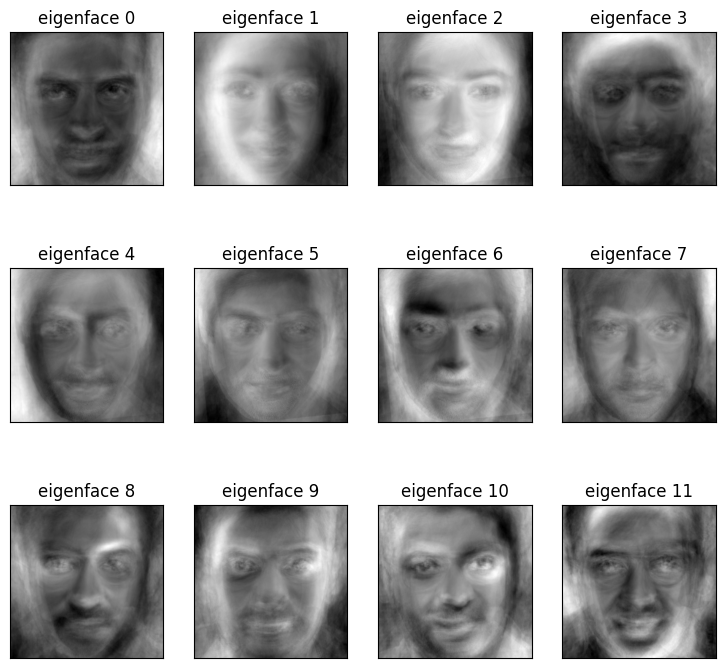

Projecting the input data on the eigenfaces orthonormal basis
(337, 150) (113, 150)


In [3]:
'''
Split data into training (75%) and testing (25%).
Use PCA to extract key features (eigenfaces) that represent the images.
Reduce dimensions for faster computation.
'''
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
n_components = 150
print(f"Extracting the top {n_components} eigenfaces from {X_train.shape[0]} faces")
pca = PCA(n_components=n_components, svd_solver='randomized', whiten=True).fit(X_train)
eigenfaces = pca.components_.reshape((n_components, h, w))
eigenface_titles = [f"eigenface {i}" for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces, eigenface_titles, h, w)
plt.show()

print("Projecting the input data on the eigenfaces orthonormal basis")
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print(X_train_pca.shape, X_test_pca.shape)


4. Apply LDA (Classification) & Train MLP Classifier

In [4]:
#Perform LDA to separate faces of different classes (people) better in reduced space.
# Train an MLPClassifier (neural network) on the transformed data to classify faces.
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_pca, y_train)
X_train_lda = lda.transform(X_train_pca)
X_test_lda = lda.transform(X_test_pca)
print("Project done...")

clf = MLPClassifier(random_state=1, hidden_layer_sizes=(10, 10), max_iter=1000, verbose=True).fit(X_train_lda, y_train)
print("Model Weights:")
model_info = [coef.shape for coef in clf.coefs_]
print(model_info)


Project done...
Iteration 1, loss = 3.07676051
Iteration 2, loss = 3.01783196
Iteration 3, loss = 2.96433650
Iteration 4, loss = 2.90964432
Iteration 5, loss = 2.85606265
Iteration 6, loss = 2.80553177
Iteration 7, loss = 2.75393808
Iteration 8, loss = 2.70479809
Iteration 9, loss = 2.65775028
Iteration 10, loss = 2.61049674
Iteration 11, loss = 2.56429333
Iteration 12, loss = 2.52066646
Iteration 13, loss = 2.47647222
Iteration 14, loss = 2.43497118
Iteration 15, loss = 2.39261710
Iteration 16, loss = 2.35152552
Iteration 17, loss = 2.31311911
Iteration 18, loss = 2.27283646
Iteration 19, loss = 2.23747668
Iteration 20, loss = 2.20001849
Iteration 21, loss = 2.16593073
Iteration 22, loss = 2.12994402
Iteration 23, loss = 2.09626036
Iteration 24, loss = 2.06298709
Iteration 25, loss = 2.03064865
Iteration 26, loss = 2.00018190
Iteration 27, loss = 1.96791338
Iteration 28, loss = 1.93760342
Iteration 29, loss = 1.90729878
Iteration 30, loss = 1.87757033
Iteration 31, loss = 1.84942095
I

In [5]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # Increase neurons in hidden layers
    activation='relu',  # Use ReLU instead of 'tanh' or 'logistic'
    solver='adam',  # 'adam' is usually better than 'sgd'
    learning_rate_init=0.001,  # Reduce learning rate for better convergence
    max_iter=500,  # Increase iterations for better training
    random_state=42
)


5. Make Predictions and Evaluate

Accuracy: 74.33628318584071


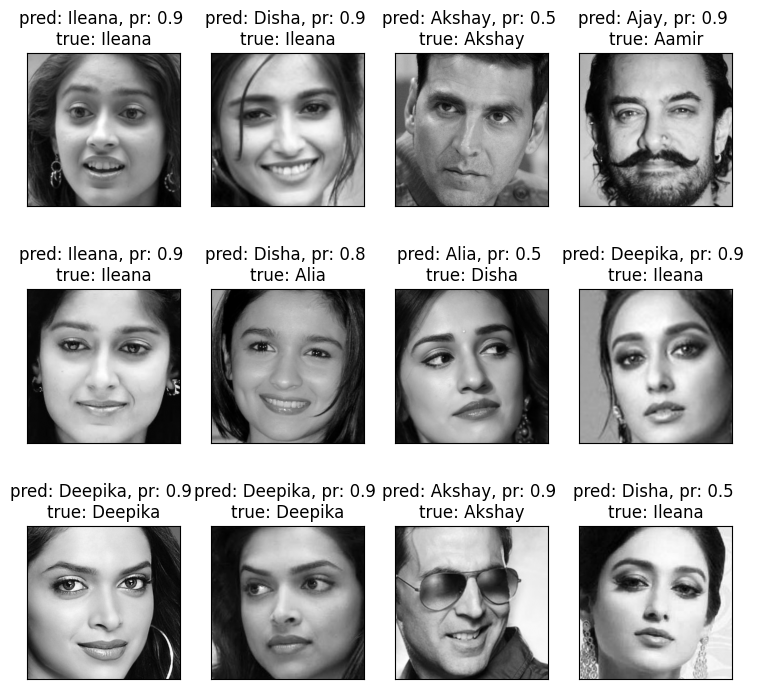

In [6]:
'''PCA (Principal Component Analysis): For dimensionality reduction and extracting eigenfaces.
LDA (Linear Discriminant Analysis): For classification of faces into distinct categories.
MLPClassifier (Neural Network): For training and prediction of face recognition.'''

clf.fit(X_train_lda, y_train)

y_pred = []
y_prob = []

for test_face in X_test_lda:    
    prob = clf.predict_proba([test_face])[0]
    class_id = np.argmax(prob)
    y_pred.append(class_id)
    y_prob.append(np.max(prob))

y_pred = np.array(y_pred)
prediction_titles = []
true_positive = 0

for i in range(y_pred.shape[0]):
    true_name = class_names[y_test[i]]
    pred_name = class_names[y_pred[i]]
    result = f'pred: {pred_name}, pr: {str(y_prob[i])[:3]} \ntrue: {true_name}'
    prediction_titles.append(result)

    if true_name == pred_name:
        true_positive += 1

print("Accuracy:", true_positive * 100 / y_pred.shape[0])

plot_gallery(X_test, prediction_titles, h, w)
plt.show()
